In [5]:
import sys
sys.path.append('..')  # Add parent directory to path

from src.susse.estimators.clearsky.rest2_model import REST2Model
from src.susse.api_clients.NASA_Power import TemporalResolution

In [8]:
from datetime import datetime
from geopy import Point

location = Point(latitude=40.7128, longitude=-74.0060)  # New York City coordinates

start_time = datetime(2023, 1, 1, 0, 0, 0)
end_time = datetime(2023, 12, 31, 0, 0, 0)

rest2 = REST2Model()
data = rest2.compute_irradiance(start_date=start_time, end_date=end_time, location=location, resolution=TemporalResolution.DAILY)

In [17]:
ghi = data.ghi

In [16]:
import pandas as pd
# create datetime rang for daily data from start_time to end_time
date_range = pd.date_range(start=start_time, end=end_time, freq='D')

In [19]:
len(ghi) == len(date_range)  # Check if lengths match

True

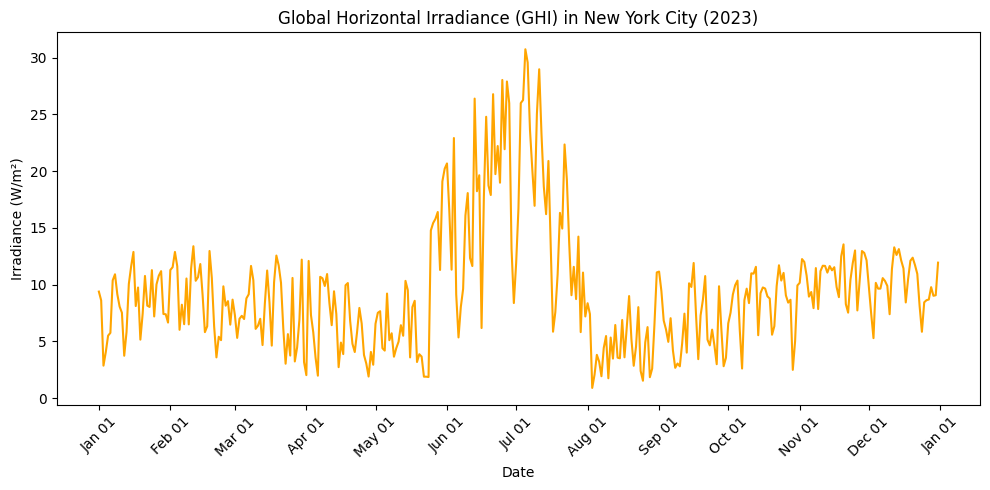

In [29]:
# pLOT ghi
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(date_range, ghi[-1], label='GHI', color='orange')
ax.set_title('Global Horizontal Irradiance (GHI) in New York City (2023)')
ax.set_xlabel('Date')
ax.set_ylabel('Irradiance (W/m²)')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [25]:
ghi.shape

(365, 365)

In [30]:
data.dhi.shape

(365, 365)